In [15]:
# =======================================
# 0. Import & cấu hình cơ bản
# =======================================
import os
import re
import glob
from typing import Dict, List, Optional
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler  # thêm cho việc scale feature

from datetime import datetime

# Đường dẫn thư mục chứa tất cả CSV điểm (mỗi file = 1 môn)
DATA_DIR = "output_final_fixed"                     # TODO: sửa lại cho đúng thư mục của bạn
WEIGHTS_FILE = "./weight/weights_used.csv"  # TODO: sửa lại nếu cần
OUTPUT_DIR = "./output_final_v2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# File behavior / survey dùng để tạo feature theo course_code
BEHAVIOR_FILE = "clean_student_data_v1.csv"    # TODO: chỉnh lại đúng path trên máy bạn

# =======================================
# 1. Định nghĩa schema chuẩn & alias
# =======================================

# Cột target
TARGET_COL = "final"

# Các feature điểm (KHÔNG gồm final)
FEATURE_SCORE_COLS = [
    "attend",
    "quiz",
    "quiz2",
    "midterm",
    "homework",
    "homework1",
    "homework2",
    "group_project",
    "individual_project",
    "practice",
    "regular",
    "speech_and_discussion",
    "project"
]

# Toàn bộ feature điểm + target (dùng cho tạo mask, xử lý chung)
CANONICAL_FEATURES = FEATURE_SCORE_COLS + [TARGET_COL]

# Cột ID/meta
ID_COLUMNS = ["student_id", "course_code", "no"]

# Map alias để nhận diện cột raw -> cột chuẩn
COLUMN_ALIASES: Dict[str, List[str]] = {
    "no": ["no", "No"],
    "student_id": ["student id", "student_id", "id"],
    "course_code": ["course_code", "course code", "course"],

    "attend": ["attend", "attendance"],
    "quiz": ["quiz"],
    "quiz2": ["quiz2"],
    "homework": ["homework", "hw", "assignment"],
    "homework1": ["homework1", "hw1"],
    "homework2": ["homework2", "hw2"],
    "midterm": ["midterm", "mid term"],
    "group_project": ["group project", "group_project"],
    "individual_project": ["individual project", "individual_project"],
    "practice": ["practice", "lab", "exercise"],
    "regular": ["regular", "participation", "classwork"],
    "speech_and_discussion": ["speech and discussion", "speech_and_discussion"],
    "project": ["project"],
    "final": ["final", "final_exam"]
}

def normalize_col_name(col: str) -> str:
    """Chuẩn hóa tên cột: lower, strip, thay space bằng '_'."""
    return re.sub(r"\s+", "_", str(col).strip().lower())

def find_canonical_for_raw(raw_col: str) -> Optional[str]:
    """Tìm xem cột raw (sau normalize) map được vào canonical nào."""
    raw_norm = normalize_col_name(raw_col)
    for canonical, aliases in COLUMN_ALIASES.items():
        for alias in aliases:
            alias_norm = normalize_col_name(alias)
            if raw_norm == alias_norm:
                return canonical
    return None


# =======================================
# 1.5. Tạo profile theo course_code từ BEHAVIOR_FILE
# =======================================

# Danh sách tên feature behavior sau khi aggregate theo course_code
BEHAVIOR_FEATURE_BY_COURSE = [
    "weekly_study_hours_by_course",
    "part_time_hours_by_course",
    "financial_support_by_course",
    "emotional_support_by_course",
]

def build_course_profile(behavior_path: str) -> pd.DataFrame:
    """
    Đọc file behavior/clean_student_data_v1_demo.csv và trả về bảng
    profile theo course_code, với các cột *_by_course (mean).
    """
    if not os.path.exists(behavior_path):
        raise FileNotFoundError(f"Không tìm thấy file behavior: {behavior_path}")

    df_beh = pd.read_csv(behavior_path)

    # Các cột gốc trong file behavior
    behavior_cols_raw = [
        "weekly_study_hours",
        "part_time_hours",
        "financial_support",
        "emotional_support",
    ]

    # Đảm bảo tồn tại đủ các cột cần thiết
    for c in behavior_cols_raw:
        if c not in df_beh.columns:
            raise ValueError(f"Thiếu cột '{c}' trong file behavior: {behavior_path}")

    # Ép kiểu numeric
    for c in behavior_cols_raw:
        df_beh[c] = pd.to_numeric(df_beh[c], errors="coerce")

    # Group theo course_code, lấy mean
    course_profile = (
        df_beh
        .groupby("course_code")[behavior_cols_raw]
        .mean()
        .reset_index()
    )

    # Đổi tên sang dạng *_by_course để rõ nghĩa
    rename_map = {
        "weekly_study_hours": "weekly_study_hours_by_course",
        "part_time_hours": "part_time_hours_by_course",
        "financial_support": "financial_support_by_course",
        "emotional_support": "emotional_support_by_course",
    }
    course_profile = course_profile.rename(columns=rename_map)

    print("Đã build course_profile từ behavior file.")
    print("Số course_code có profile:", course_profile.shape[0])
    return course_profile
    
def build_scaled_course_profile_for_inference(
    artifacts: dict,
    behavior_path: str
) -> pd.DataFrame:
    """
    Dùng scaler_behavior đã lưu trong artifacts để scale profile theo course_code.
    Trả về DataFrame: ['course_code'] + BEHAVIOR_FEATURE_BY_COURSE (đã scale).
    """
    course_profile_raw = build_course_profile(behavior_path)

    # Lấy danh sách cột behavior đã dùng khi train từ artifacts (nếu có)
    behavior_feature_cols = artifacts.get("behavior_feature_cols", BEHAVIOR_FEATURE_BY_COURSE)
    scaler_behavior = artifacts.get("scaler_behavior", None)

    if scaler_behavior is None:
        # Không có scaler thì trả profile raw, vẫn merge được (nhưng khác so với lúc train)
        print("[WARN] artifacts không có scaler_behavior, dùng raw behavior profile.")
        return course_profile_raw[["course_code"] + behavior_feature_cols].copy()
    
    # Scale các cột behavior
    mat = course_profile_raw[behavior_feature_cols].fillna(0.0)
    mat_scaled = scaler_behavior.transform(mat)
    course_profile_raw[behavior_feature_cols] = mat_scaled

    course_profile_scaled = course_profile_raw[["course_code"] + behavior_feature_cols].copy()
    return course_profile_scaled

def add_course_profile_features(
    df_main: pd.DataFrame,
    course_profile: pd.DataFrame
) -> pd.DataFrame:
    """
    LEFT JOIN profile theo course_code vào df_main.
    """
    df_merged = df_main.merge(course_profile, on="course_code", how="left")

    # Thống kê coverage
    miss = df_merged["weekly_study_hours_by_course"].isna().sum()
    total = len(df_merged)
    print(f"Course_profile merge: {total - miss}/{total} dòng có profile "
          f"({100 * (total - miss) / max(total, 1):.2f}%).")
    return df_merged


# =======================================
# 2. Load weights_used.csv & tạo baseline
# =======================================

def load_weights(weights_file: str) -> Dict[str, Dict[str, float]]:
    """
    Đọc weights_used.csv và trả về:
    {
      course_code: {
          canonical_feature: weight,
          ...
      },
      ...
    }
    """
    if not os.path.exists(weights_file):
        print("Không tìm thấy weights_used.csv, bỏ qua phần baseline.")
        return {}

    wdf = pd.read_csv(weights_file)
    # Chuẩn hóa course_code & component
    if "course_code" not in wdf.columns or "component" not in wdf.columns or "weight" not in wdf.columns:
        print("File weights_used.csv không đúng format kỳ vọng (cần course_code, component, weight).")
        return {}

    wdf["course_code"] = wdf["course_code"].astype(str).str.strip()
    wdf["component_norm"] = wdf["component"].apply(find_canonical_for_raw)

    # Bỏ các component không map được
    wdf = wdf[~wdf["component_norm"].isna()].copy()

    weights_by_course: Dict[str, Dict[str, float]] = {}
    for _, row in wdf.iterrows():
        course = row["course_code"]
        comp = row["component_norm"]
        weight = float(row["weight"])
        if course not in weights_by_course:
            weights_by_course[course] = {}
        weights_by_course[course][comp] = weights_by_course[course].get(comp, 0.0) + weight

    print("Đã load weights cho", len(weights_by_course), "course.")
    return weights_by_course

def add_baseline_from_weights(data: pd.DataFrame,
                              weights_by_course: Dict[str, Dict[str, float]]) -> pd.DataFrame:
    """
    Tính baseline_final_weighted = sum(component_score * weight)
    cho từng course_code (nếu có weight). Bỏ qua component = final
    để tránh dùng target trực tiếp.
    """
    data = data.copy()
    data["baseline_final_weighted"] = np.nan

    if not weights_by_course:
        print("Không có weights_by_course, baseline_final_weighted sẽ toàn NaN.")
        return data

    # Chuẩn hóa course_code để join với weights
    data["course_code_norm"] = data["course_code"].astype(str).str.strip()

    for course, comp_weights in weights_by_course.items():
        mask_course = data["course_code_norm"] == course
        if not mask_course.any():
            continue

        idx = data.index[mask_course]
        baseline = pd.Series(0.0, index=idx)

        for comp, w in comp_weights.items():
            if comp == TARGET_COL:
                # không dùng final làm baseline
                continue
            if comp in data.columns:
                baseline += data.loc[idx, comp].astype(float).fillna(0.0) * w

        data.loc[idx, "baseline_final_weighted"] = baseline

    # Không cần cột norm nữa
    data = data.drop(columns=["course_code_norm"])
    return data

# =======================================
# 3. Hàm xử lý 1 file course
# =======================================

def load_and_process_course_file(path: str) -> pd.DataFrame:
    """
    Đọc một file CSV (1 môn), chuẩn hóa cột, map sang schema chuẩn,
    tạo mask, trả về DataFrame thống nhất.
    """
    print(f"Đang đọc file: {path}")
    df_raw = pd.read_csv(path)

    # Drop cột rác Unnamed
    unnamed_cols = [c for c in df_raw.columns if normalize_col_name(c).startswith("unnamed")]
    if unnamed_cols:
        print(f"  - Drop cột rác: {unnamed_cols}")
        df_raw = df_raw.drop(columns=unnamed_cols)

    # Chuẩn hóa tên cột
    original_cols = list(df_raw.columns)
    col_norm_map = {c: normalize_col_name(c) for c in original_cols}
    df_raw = df_raw.rename(columns=col_norm_map)

    # Map alias thủ công cho student_id, course_code, no nếu cần
    if "student_id" not in df_raw.columns:
        for c in list(df_raw.columns):
            if find_canonical_for_raw(c) == "student_id":
                df_raw = df_raw.rename(columns={c: "student_id"})
                break

    if "course_code" not in df_raw.columns:
        for c in list(df_raw.columns):
            if find_canonical_for_raw(c) == "course_code":
                df_raw = df_raw.rename(columns={c: "course_code"})
                break

    if "no" not in df_raw.columns:
        for c in list(df_raw.columns):
            if find_canonical_for_raw(c) == "no":
                df_raw = df_raw.rename(columns={c: "no"})
                break

    # Xử lý student_id: ép sang string
    if "student_id" in df_raw.columns:
        df_raw["student_id"] = df_raw["student_id"].astype(str)
    else:
        df_raw["student_id"] = df_raw.index.astype(str)

    # Xử lý course_code: nếu không có, lấy tên file làm course_code
    if "course_code" not in df_raw.columns:
        fname = os.path.basename(path)
        base, _ = os.path.splitext(fname)
        df_raw["course_code"] = base

    # Tạo DataFrame output theo schema chuẩn
    df_out = pd.DataFrame(index=df_raw.index)
    df_out["student_id"] = df_raw["student_id"]
    df_out["course_code"] = df_raw["course_code"]
    df_out["no"] = df_raw["no"] if "no" in df_raw.columns else np.arange(len(df_raw)) + 1

    # Ghi nhận cột nào course này thực sự có
    course_has_feature = {f: False for f in CANONICAL_FEATURES}

    # Tạm lưu mapping canonical -> raw_col
    temp_feature_cols: Dict[str, str] = {}

    for raw_col in df_raw.columns:
        canonical = find_canonical_for_raw(raw_col)
        if canonical in CANONICAL_FEATURES:
            temp_feature_cols[canonical] = raw_col
            course_has_feature[canonical] = True

    # Xử lý đặc biệt quiz1/quiz2, homework1/homework2 → tạo quiz/homework chung
    if "quiz1" in df_raw.columns and "quiz2" in df_raw.columns:
        df_out["quiz"] = df_raw["quiz1"].combine(df_raw["quiz2"], np.nanmean)
        course_has_feature["quiz"] = True

    if "homework1" in df_raw.columns and "homework2" in df_raw.columns:
        df_out["homework"] = df_raw["homework1"].combine(df_raw["homework2"], np.nanmean)
        course_has_feature["homework"] = True

    # Copy dữ liệu từ raw -> canonical
    for feat in CANONICAL_FEATURES:
        if feat in df_out.columns:
            # đã được tạo ở trên (quiz/homework gộp)
            continue
        if feat in temp_feature_cols:
            raw_col = temp_feature_cols[feat]
            df_out[feat] = pd.to_numeric(df_raw[raw_col], errors="coerce")
        else:
            df_out[feat] = np.nan  # course này không có cột này

    # Tạo mask cho từng feature (kể cả final, để biết môn có cột final hay không)
    for feat in CANONICAL_FEATURES:
        mask_col = f"{feat}_mask"
        if course_has_feature[feat]:
            df_out[mask_col] = 1
        else:
            df_out[mask_col] = 0

    # Loại bỏ các dòng quá "rác" (rất ít điểm)
    feature_cols_only = CANONICAL_FEATURES.copy()
    non_null_count = df_out[feature_cols_only].notnull().sum(axis=1)
    before = len(df_out)
    df_out = df_out[non_null_count >= 2].copy()
    after = len(df_out)
    if before != after:
        print(f"  - Loại {before - after} dòng có quá ít điểm (non-null < 2)")

    return df_out.reset_index(drop=True)

# =======================================
# 4. Đọc toàn bộ folder & merge + thêm behavior
# =======================================

def load_all_courses(data_dir: str) -> pd.DataFrame:
    csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"Không tìm thấy CSV nào trong thư mục: {data_dir}")

    all_dfs = []
    for path in csv_files:
        # Bỏ qua file weights nếu nằm chung thư mục
        if os.path.basename(path).startswith("weights_used"):
            continue
        df_course = load_and_process_course_file(path)
        all_dfs.append(df_course)

    data = pd.concat(all_dfs, ignore_index=True)
    print("Kích thước data sau merge:", data.shape)
    return data

# Load dữ liệu courses
data = load_all_courses(DATA_DIR)

# Load weights & tính baseline_final_weighted
weights_by_course = load_weights(WEIGHTS_FILE)
data = add_baseline_from_weights(data, weights_by_course)

# Thêm feature behavior theo course_code từ BEHAVIOR_FILE
course_profile = build_course_profile(BEHAVIOR_FILE)
data = add_course_profile_features(data, course_profile)

# Lưu synthetic_training_sample để dễ debug/manual check
synthetic_path = os.path.join(OUTPUT_DIR, "synthetic_training_with_behavior_v2.csv")
data.to_csv(synthetic_path, index=False, encoding="utf-8-sig")
print(f"Đã lưu synthetic_training_with_behavior_v2.csv tại: {synthetic_path}")


Đang đọc file: output_final_fixed\CHE 101.csv
Đang đọc file: output_final_fixed\CMU-CS 246.csv
Đang đọc file: output_final_fixed\CMU-CS 252.csv
Đang đọc file: output_final_fixed\CMU-CS 297.csv
Đang đọc file: output_final_fixed\CMU-CS 303.csv
Đang đọc file: output_final_fixed\CMU-CS 311.csv
Đang đọc file: output_final_fixed\CMU-CS 316.csv
Đang đọc file: output_final_fixed\CMU-CS 445.csv
Đang đọc file: output_final_fixed\CMU-CS 447.csv
Đang đọc file: output_final_fixed\CMU-CS 462.csv
Đang đọc file: output_final_fixed\CMU-ENG 130.csv
  - Loại 1 dòng có quá ít điểm (non-null < 2)
Đang đọc file: output_final_fixed\CMU-ENG 230.csv
Đang đọc file: output_final_fixed\CMU-IS 401.csv
Đang đọc file: output_final_fixed\CMU-IS 432.csv
Đang đọc file: output_final_fixed\CMU-SE 100.csv
Đang đọc file: output_final_fixed\CMU-SE 214.csv
Đang đọc file: output_final_fixed\CMU-SE 252.csv
Đang đọc file: output_final_fixed\CMU-SE 303.csv
Đang đọc file: output_final_fixed\COM 141.csv
Đang đọc file: output_final


========== EDA: Phổ điểm & One-hot matrix ==========


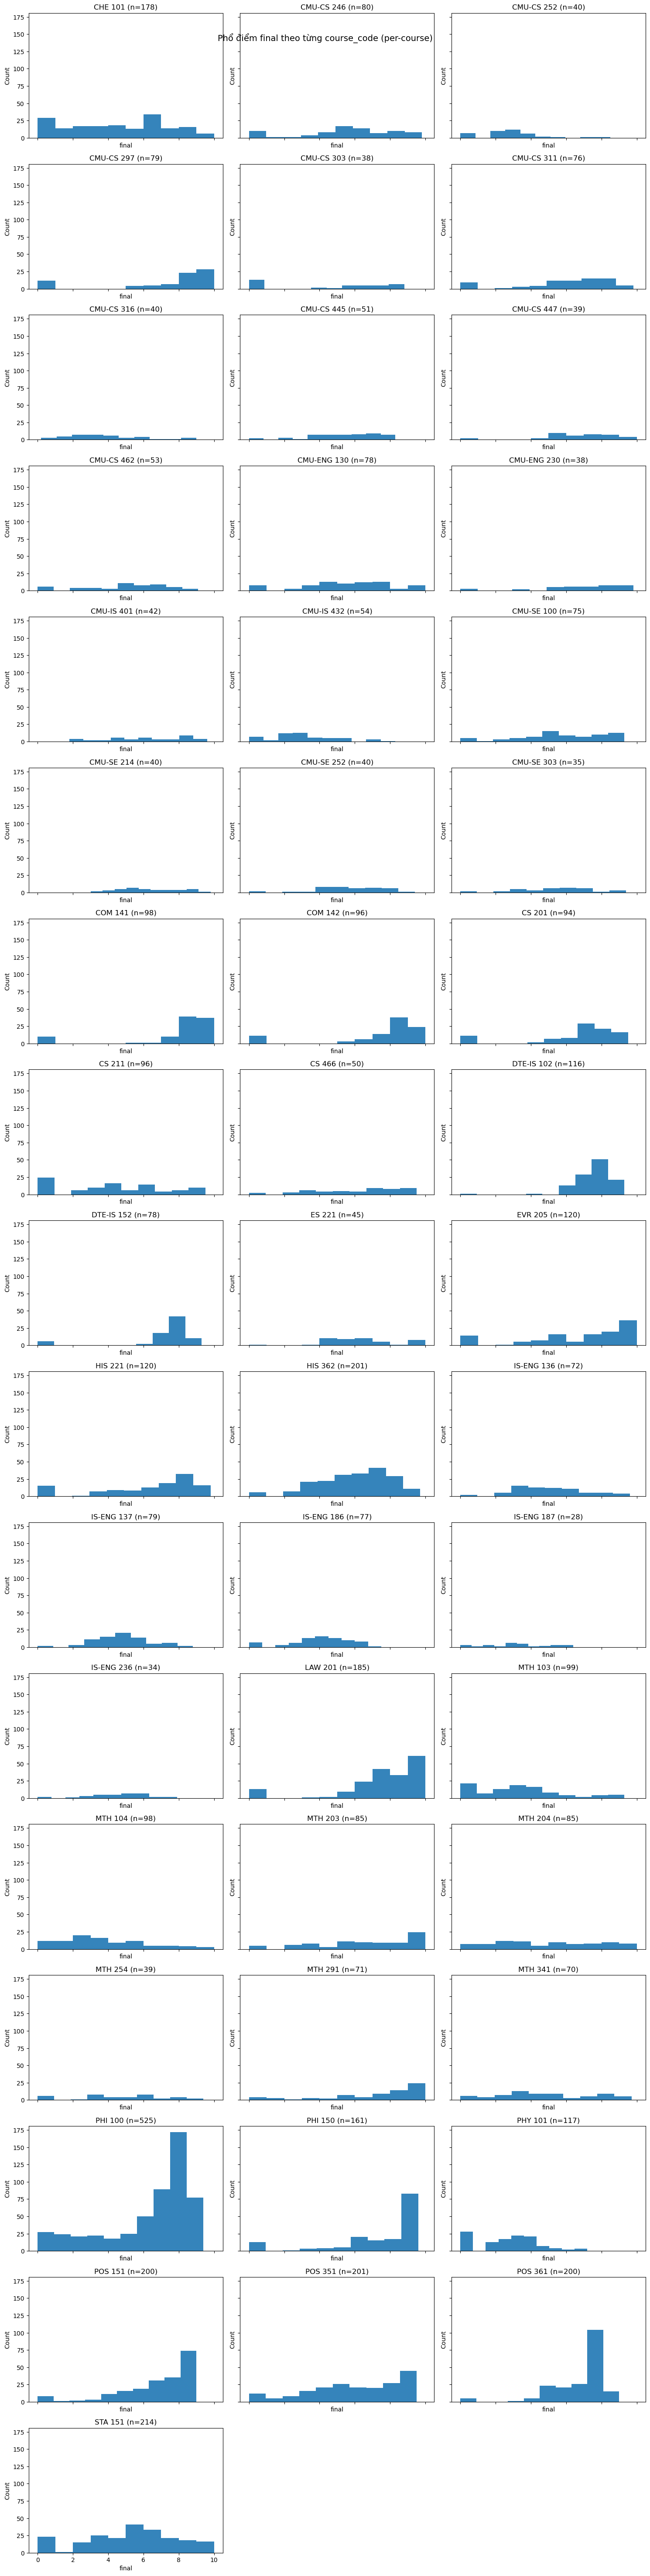

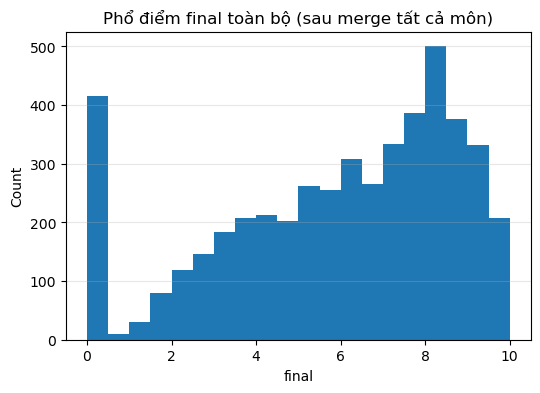

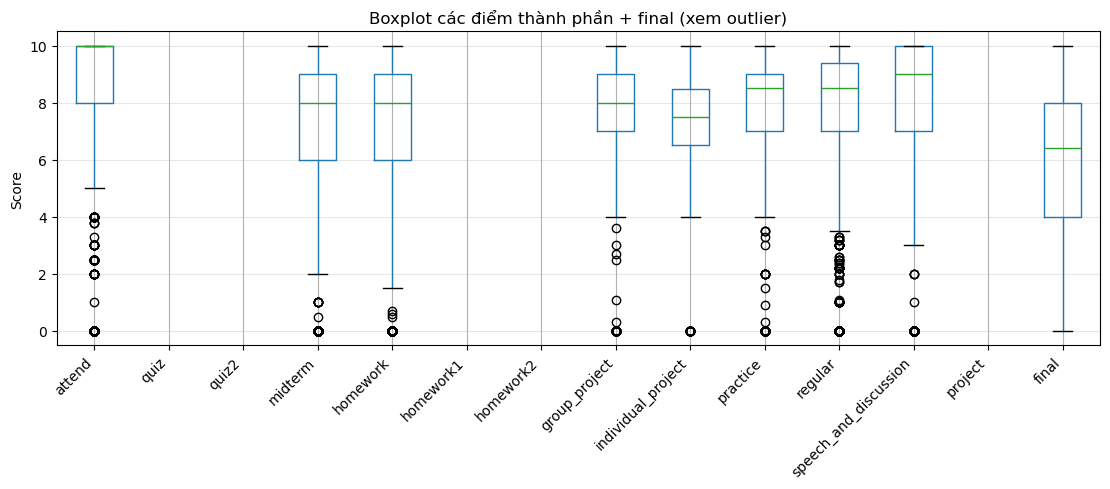


=== Correlation giữa course one-hot và final ===
                       final
final               1.000000
course_LAW 201      0.118840
course_PHI 150      0.107153
course_DTE-IS 102   0.097451
course_COM 141      0.097062
course_POS 361      0.081526
course_POS 151      0.077033
course_COM 142      0.076713
course_PHI 100      0.069675
course_DTE-IS 152   0.064020
course_MTH 291      0.057873
course_CMU-CS 297   0.054363
course_EVR 205      0.045886
course_CS 201       0.036730
course_CMU-ENG 230  0.033124
course_MTH 203      0.032332
course_HIS 221      0.023601
course_CMU-CS 447   0.017662
course_CMU-SE 214   0.014938
course_CS 466       0.011671
course_HIS 362      0.011655
course_CMU-IS 401   0.010980
course_POS 351      0.008853
course_CMU-CS 311   0.008369
course_ES 221       0.002440
course_CMU-SE 100  -0.004824
course_CMU-SE 252  -0.007780
course_CMU-CS 246  -0.012860
course_CMU-SE 303  -0.017190
course_CMU-CS 445  -0.017592
course_CMU-ENG 130 -0.020902
course_CMU-CS 462  -0.

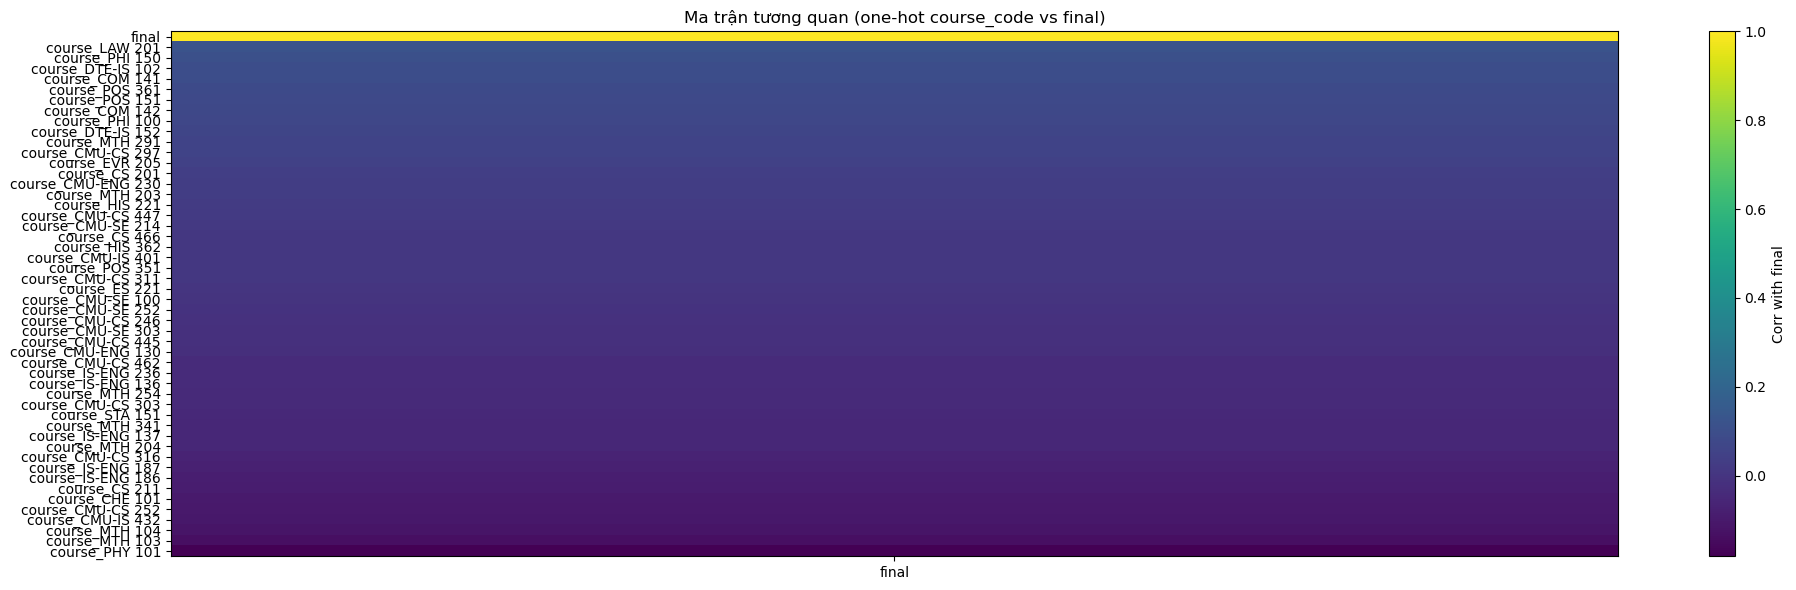


=== Thống kê outlier theo z-score (|z| > 3.0) ===
attend                        : 180 outlier
midterm                       : 0 outlier
homework                      : 0 outlier
group_project                 : 0 outlier
individual_project            : 0 outlier
practice                      : 94 outlier
regular                       : 0 outlier
speech_and_discussion         : 0 outlier
final                         : 0 outlier


In [16]:

# =======================================
# 5. EDA & TRỰC QUAN HÓA TRƯỚC KHI TRAIN
#    - Phổ điểm theo từng môn (coi như "trước khi merge theo môn")
#    - Phổ điểm toàn bộ sau merge
#    - Boxplot để xem outlier
#    - One-hot matrix (course -> final)
#    - Thống kê outlier (z-score)
# =======================================

def plot_final_distribution_by_course(df: pd.DataFrame,
                                      target_col: str = TARGET_COL):
    """
    Vẽ histogram final cho từng course_code (mỗi subplot là 1 môn).
    """
    if target_col not in df.columns:
        print(f"[WARN] Không có cột target '{target_col}' để vẽ phân phối.")
        return

    df_valid = df[df[target_col].notnull()].copy()
    if df_valid.empty:
        print("[WARN] Không có giá trị final hợp lệ để vẽ.")
        return

    courses = sorted(df_valid["course_code"].unique())
    n_courses = len(courses)
    if n_courses == 0:
        print("[WARN] Không có course_code để vẽ.")
        return

    ncols = 3
    nrows = math.ceil(n_courses / ncols)

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5 * ncols, 3.5 * nrows),
                             sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)

    for idx, course in enumerate(courses):
        ax = axes[idx]
        subset = df_valid[df_valid["course_code"] == course][target_col]
        ax.hist(subset, bins=10, alpha=0.9)
        ax.set_title(f"{course} (n={len(subset)})")
        ax.set_xlabel(target_col)
        ax.set_ylabel("Count")

    # Ẩn subplot thừa
    for j in range(len(courses), len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Phổ điểm {target_col} theo từng course_code (per-course)", fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_overall_final_distribution(df: pd.DataFrame,
                                    target_col: str = TARGET_COL):
    """
    Vẽ histogram final cho toàn bộ dataset sau khi merge (all courses).
    """
    if target_col not in df.columns:
        print(f"[WARN] Không có cột target '{target_col}' để vẽ phân phối.")
        return

    df_valid = df[df[target_col].notnull()].copy()
    if df_valid.empty:
        print("[WARN] Không có giá trị final hợp lệ để vẽ.")
        return

    plt.figure(figsize=(6, 4))
    plt.hist(df_valid[target_col], bins=20)
    plt.title(f"Phổ điểm {target_col} toàn bộ (sau merge tất cả môn)")
    plt.xlabel(target_col)
    plt.ylabel("Count")
    plt.grid(axis="y", alpha=0.3)
    plt.show()


def plot_score_boxplots(df: pd.DataFrame):
    """
    Vẽ boxplot cho các cột điểm để nhìn outlier (outline).
    """
    score_cols = [c for c in FEATURE_SCORE_COLS + [TARGET_COL] if c in df.columns]
    if not score_cols:
        print("[WARN] Không có cột điểm nào để vẽ boxplot.")
        return

    plt.figure(figsize=(max(8, len(score_cols) * 0.8), 5))
    df[score_cols].boxplot()
    plt.title("Boxplot các điểm thành phần + final (xem outlier)")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Score")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_onehot_course_correlation(df: pd.DataFrame,
                                   target_col: str = TARGET_COL):
    """
    Tạo one-hot matrix cho course_code và vẽ correlation với final.
    Hiển thị dạng heatmap đơn giản + in bảng correlation.
    """
    if "course_code" not in df.columns:
        print("[WARN] Không có course_code để one-hot.")
        return
    if target_col not in df.columns:
        print(f"[WARN] Không có cột '{target_col}' để tính correlation.")
        return

    df_valid = df[[target_col, "course_code"]].dropna()
    if df_valid.empty:
        print("[WARN] Không có đủ dữ liệu để tính correlation one-hot.")
        return

    # One-hot cho course_code
    course_dummies = pd.get_dummies(df_valid["course_code"], prefix="course")

    # Gộp lại với final để tính corr
    tmp = pd.concat([course_dummies, df_valid[[target_col]].reset_index(drop=True)], axis=1)
    corr = tmp.corr()[[target_col]].sort_values(by=target_col, ascending=False)

    print("\n=== Correlation giữa course one-hot và final ===")
    print(corr)

    # Vẽ heatmap đơn giản
    plt.figure(figsize=(max(6, len(corr) * 0.4), 6))
    plt.imshow(corr.values, aspect="auto")
    plt.colorbar(label=f"Corr with {target_col}")
    plt.yticks(range(len(corr.index)), corr.index)
    plt.xticks([0], [target_col])
    plt.title("Ma trận tương quan (one-hot course_code vs final)")
    plt.tight_layout()
    plt.show()


def detect_outliers_zscore(df: pd.DataFrame,
                           cols: Optional[List[str]] = None,
                           z_thresh: float = 3.0):
    """
    Thống kê số lượng outlier (|z| > z_thresh) cho từng feature.
    """
    if cols is None:
        cols = [c for c in FEATURE_SCORE_COLS + [TARGET_COL] if c in df.columns]

    outlier_counts = {}
    for c in cols:
        series = df[c].astype(float)
        series = series.replace([np.inf, -np.inf], np.nan).dropna()
        if series.empty:
            continue
        mean = series.mean()
        std = series.std(ddof=0)
        if std == 0:
            outlier_counts[c] = 0
            continue
        z = np.abs((series - mean) / std)
        outlier_counts[c] = int((z > z_thresh).sum())

    print(f"\n=== Thống kê outlier theo z-score (|z| > {z_thresh}) ===")
    for c, cnt in outlier_counts.items():
        print(f"{c:30s}: {cnt} outlier")


# ===========================
# GỌI CÁC HÀM EDA
# ===========================
print("\n========== EDA: Phổ điểm & One-hot matrix ==========")

# 1) Phổ điểm final theo từng môn (coi như trước khi merge theo môn)
plot_final_distribution_by_course(data, target_col=TARGET_COL)

# 2) Phổ điểm final toàn bộ sau merge
plot_overall_final_distribution(data, target_col=TARGET_COL)

# 3) Boxplot xem outlier cho các điểm thành phần
plot_score_boxplots(data)

# 4) One-hot matrix: course_code vs final
plot_onehot_course_correlation(data, target_col=TARGET_COL)

# 5) Thống kê outlier theo z-score
detect_outliers_zscore(data)

In [2]:

# =======================================
# 5. Chuẩn bị dữ liệu train/test (KHÔNG leak final) + scale behavior
# =======================================

# Chỉ dùng những dòng có final thật để train
data_train = data[~data[TARGET_COL].isna()].copy()
print("Số dòng có final (dùng để train):", len(data_train))

# Nếu baseline có NaN, fill bằng một giá trị cố định và LƯU lại
if "baseline_final_weighted" not in data_train.columns:
    data_train["baseline_final_weighted"] = np.nan

# Chọn baseline_fill_value: 
baseline_fill_value = data_train["baseline_final_weighted"].mean()
if np.isnan(baseline_fill_value):
    baseline_fill_value = 5.0  # fallback an toàn

data_train["baseline_final_weighted"] = data_train["baseline_final_weighted"].fillna(baseline_fill_value)

# Scale các behavior feature theo course_code
scaler_behavior = StandardScaler()
# fit trên phần train (có final)
behavior_train_raw = data_train[BEHAVIOR_FEATURE_BY_COURSE].fillna(0.0)
scaler_behavior.fit(behavior_train_raw)

# transform trên data_train
data_train[BEHAVIOR_FEATURE_BY_COURSE] = scaler_behavior.transform(behavior_train_raw)

# transform trên toàn bộ data để dùng cho prediction sau này
behavior_full_raw = data[BEHAVIOR_FEATURE_BY_COURSE].fillna(0.0)
data[BEHAVIOR_FEATURE_BY_COURSE] = scaler_behavior.transform(behavior_full_raw)

# Tạo danh sách cột feature & mask
# Điểm thành phần gốc
feature_cols = FEATURE_SCORE_COLS.copy()
# Thêm các feature behavior theo course_code đã scale
feature_cols += BEHAVIOR_FEATURE_BY_COURSE

mask_cols = [f"{f}_mask" for f in CANONICAL_FEATURES]  # mask cho tất cả (kể cả final_mask)

# Numeric features: điểm + mask + baseline + behavior
X_num = data_train[feature_cols + mask_cols + ["baseline_final_weighted"]].copy()
X_num = X_num.fillna(0.0)  # phòng hờ NaN

# One-hot cho course_code
course_dummies = pd.get_dummies(data_train["course_code"], prefix="course")
X = pd.concat([X_num, course_dummies], axis=1)

# Target
y = data_train[TARGET_COL].astype(float)

print("Shape X:", X.shape, "| Shape y:", y.shape)

# Lưu lại index để đánh giá theo course_code ở valid set
idx_all = data_train.index.to_numpy()

X_train, X_valid, y_train, y_valid, idx_train, idx_valid = train_test_split(
    X, y, idx_all, test_size=0.2, random_state=42
)

# =======================================
# 6. GradientBoosting + Early Stopping
# =======================================

# Dùng thêm 1 model GradientBoosting với nhiều cây hơn để monitoring
gb_monitor = GradientBoostingRegressor(
    n_estimators=1000,      # nhiều hơn 300 để có dư biên theo dõi
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_monitor.fit(X_train, y_train)

n_stages = gb_monitor.n_estimators_

stages = []
train_mae_list = []
valid_mae_list = []
train_rmse_list = []
valid_rmse_list = []
train_r2_list = []
valid_r2_list = []

best_valid_mae = np.inf
best_n_estimators = None
best_valid_rmse = None
best_valid_r2 = None

for i, (y_tr_pred, y_val_pred) in enumerate(
    zip(gb_monitor.staged_predict(X_train), gb_monitor.staged_predict(X_valid)),
    start=1
):
    mae_tr = mean_absolute_error(y_train, y_tr_pred)
    mae_val = mean_absolute_error(y_valid, y_val_pred)
    rmse_tr = np.sqrt(mean_squared_error(y_train, y_tr_pred))
    rmse_val = np.sqrt(mean_squared_error(y_valid, y_val_pred))
    r2_tr = r2_score(y_train, y_tr_pred)
    r2_val = r2_score(y_valid, y_val_pred)

    stages.append(i)
    train_mae_list.append(mae_tr)
    valid_mae_list.append(mae_val)
    train_rmse_list.append(rmse_tr)
    valid_rmse_list.append(rmse_val)
    train_r2_list.append(r2_tr)
    valid_r2_list.append(r2_val)

    # Early stopping theo MAE valid
    if mae_val < best_valid_mae:
        best_valid_mae = mae_val
        best_n_estimators = i
        best_valid_rmse = rmse_val
        best_valid_r2 = r2_val

print(f"\n[Monitoring] Đã log {len(stages)} stages (n_estimators).")
print(f"[EarlyStopping] Best n_estimators = {best_n_estimators} | "
      f"MAE_valid = {best_valid_mae:.4f}, RMSE_valid = {best_valid_rmse:.4f}, R2_valid = {best_valid_r2:.4f}")

# Train lại 1 model với số cây tối ưu (early-stopped)
gb_model_es = GradientBoostingRegressor(
    n_estimators=best_n_estimators,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb_model_es.fit(X_train, y_train)

y_pred_gb_es = gb_model_es.predict(X_valid)
mae_gb_es = mean_absolute_error(y_valid, y_pred_gb_es)
rmse_gb_es = np.sqrt(mean_squared_error(y_valid, y_pred_gb_es))
r2_gb_es = r2_score(y_valid, y_pred_gb_es)

print("\n==== Kết quả GradientBoosting (Early Stopping) ====")
print(f"MAE  : {mae_gb_es:.4f}")
print(f"RMSE : {rmse_gb_es:.4f}")
print(f"R^2  : {r2_gb_es:.4f}")


Số dòng có final (dùng để train): 4830
Shape X: (4830, 81) | Shape y: (4830,)

[Monitoring] Đã log 1000 stages (n_estimators).
[EarlyStopping] Best n_estimators = 693 | MAE_valid = 1.2329, RMSE_valid = 1.6422, R2_valid = 0.6401

==== Kết quả GradientBoosting (Early Stopping) ====
MAE  : 1.2329
RMSE : 1.6422
R^2  : 0.6401


In [3]:

# =======================================
# 7. Feature importance (đặc biệt xem 5 behavior feature)
# =======================================

feature_names = list(X.columns)
importances = gb_model_es.feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

fi_df = fi_df.sort_values("importance", ascending=False)

# Lưu full feature importance
fi_path = os.path.join(OUTPUT_DIR, "feature_importances_gradient_boosting.csv")
fi_df.to_csv(fi_path, index=False, encoding="utf-8-sig")
print(f"\nĐã lưu feature importance vào: {fi_path}")

print("\nTop 30 feature quan trọng nhất:")
print(fi_df.head(30))

print("\nFeature importance của các behavior feature:")
print(fi_df[fi_df["feature"].isin(BEHAVIOR_FEATURE_BY_COURSE)])

# =======================================
# 8. Bảng metrics theo từng course_code (dựa trên tập VALID)
# =======================================

def eval_by_course(
    data_train: pd.DataFrame,
    y_true_all: pd.Series,
    y_pred_all: np.ndarray,
    idx_used: np.ndarray,
    course_col: str = "course_code"
) -> pd.DataFrame:
    """
    Đánh giá MAE/RMSE/R2 theo từng course_code,
    trên subset được chọn bởi idx_used (vd: idx_valid).
    """
    # Subset theo index valid
    df_sub = data_train.loc[idx_used].copy()
    y_true_sub = y_true_all.loc[idx_used]
    y_pred_sub = pd.Series(y_pred_all, index=idx_used)

    rows = []
    for course, sub in df_sub.groupby(course_col):
        idx = sub.index
        yt = y_true_sub.loc[idx]
        yp = y_pred_sub.loc[idx]
        if len(sub) < 3:
            # quá ít sample, metric sẽ không stable, nhưng vẫn báo
            mae_c = mean_absolute_error(yt, yp)
            mse_c = mean_squared_error(yt, yp)
            rmse_c = np.sqrt(mse_c)
            try:
                r2_c = r2_score(yt, yp)
            except Exception:
                r2_c = np.nan
        else:
            mae_c = mean_absolute_error(yt, yp)
            mse_c = mean_squared_error(yt, yp)
            rmse_c = np.sqrt(mse_c)
            r2_c = r2_score(yt, yp)
        rows.append((course, len(sub), mae_c, rmse_c, r2_c))
    return pd.DataFrame(rows, columns=["course_code", "n_valid", "MAE", "RMSE", "R2"])


print("\n==== Metrics theo course_code - GradientBoosting (valid set) ====")
df_course_gb = eval_by_course(data_train, y, y_pred_gb_es, idx_valid)
print(df_course_gb.sort_values("R2"))

# Lưu ra file CSV để xem kỹ trong Excel
df_course_gb.to_csv(os.path.join(OUTPUT_DIR, "course_metrics_gradient_boosting.csv"), index=False, encoding="utf-8-sig")

# =======================================
# 9. Dự đoán final cho toàn bộ data
# =======================================

# Chuẩn bị baseline cho toàn bộ data
if "baseline_final_weighted" not in data.columns:
    data["baseline_final_weighted"] = np.nan

baseline_mean_all = data["baseline_final_weighted"].mean()
data["baseline_final_weighted"] = data["baseline_final_weighted"].fillna(baseline_mean_all)

# X_full cho toàn bộ data
X_num_full = data[feature_cols + mask_cols + ["baseline_final_weighted"]].copy()
X_num_full = X_num_full.fillna(0.0)

course_dummies_full = pd.get_dummies(data["course_code"], prefix="course")

# Đồng bộ cột one-hot với phase train
for col in course_dummies.columns:
    if col not in course_dummies_full.columns:
        course_dummies_full[col] = 0
course_dummies_full = course_dummies_full[course_dummies.columns]

X_full = pd.concat([X_num_full, course_dummies_full], axis=1)

# Dự đoán bằng gb_model_es
data["pred_final_gb"] = gb_model_es.predict(X_full)

pred_csv_path = os.path.join(OUTPUT_DIR, "predictions_with_final_v2.csv")
data.to_csv(pred_csv_path, index=False, encoding="utf-8-sig")
print(f"\nĐã lưu dự đoán vào: {pred_csv_path}")
print("\n==== Metrics theo course_code - GradientBoosting (valid set) ====")
df_course_gb = eval_by_course(data_train, y, y_pred_gb_es, idx_valid)
print(df_course_gb.sort_values("R2"))



Đã lưu feature importance vào: ./output_final_v2\feature_importances_gradient_boosting.csv

Top 30 feature quan trọng nhất:
                         feature  importance
31       baseline_final_weighted    0.530716
0                         attend    0.208800
13  weekly_study_hours_by_course    0.030334
20                  midterm_mask    0.029415
10                       regular    0.025136
15   financial_support_by_course    0.022570
3                        midterm    0.015449
4                       homework    0.014362
14     part_time_hours_by_course    0.010670
11         speech_and_discussion    0.008798
68                course_MTH 104    0.008461
38             course_CMU-CS 316    0.007389
58                course_EVR 205    0.007046
67                course_MTH 103    0.006507
9                       practice    0.006380
69                course_MTH 203    0.005933
7                  group_project    0.005267
74                course_PHI 100    0.005145
28    speech_and_dis

In [4]:
save_dir = r"E:\TrainPrediction\images1"
os.makedirs(save_dir, exist_ok=True)

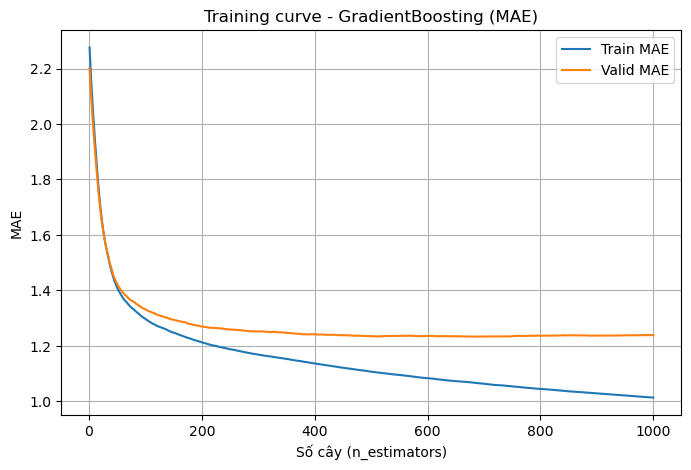

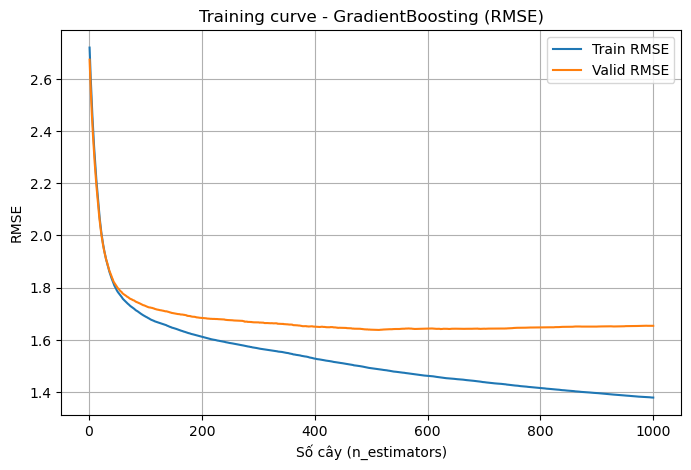

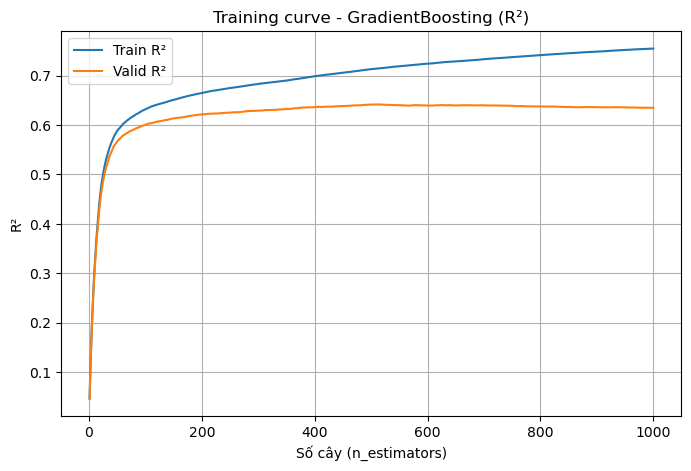

In [5]:
# =======================================
# 6c. Plot training curves cho GradientBoosting
# =======================================

# MAE train vs valid
plt.figure(figsize=(8, 5))
plt.plot(stages, train_mae_list, label="Train MAE")
plt.plot(stages, valid_mae_list, label="Valid MAE")
plt.xlabel("Số cây (n_estimators)")
plt.ylabel("MAE")
plt.title("Training curve - GradientBoosting (MAE)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Training curve - GradientBoosting (MAE).png"))
plt.show()

# RMSE train vs valid
plt.figure(figsize=(8, 5))
plt.plot(stages, train_rmse_list, label="Train RMSE")
plt.plot(stages, valid_rmse_list, label="Valid RMSE")
plt.xlabel("Số cây (n_estimators)")
plt.ylabel("RMSE")
plt.title("Training curve - GradientBoosting (RMSE)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Training curve - GradientBoosting (RMSE).png"))
plt.show()

# R² train vs valid
plt.figure(figsize=(8, 5))
plt.plot(stages, train_r2_list, label="Train R²")
plt.plot(stages, valid_r2_list, label="Valid R²")
plt.xlabel("Số cây (n_estimators)")
plt.ylabel("R²")
plt.title("Training curve - GradientBoosting (R²)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Training curve - GradientBoosting (R²).png"))
plt.show()


In [6]:
# =======================================
# 6d. Learning curve cho GradientBoosting (MAE ~ training size)
# =======================================

train_fracs = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]  # tỷ lệ dữ liệu train sử dụng
lc_results = []

# Để reproducible
rng = np.random.RandomState(42)
n_total = len(X)

for frac in train_fracs:
    n_sub = int(n_total * frac)
    idx_sub = rng.choice(n_total, size=n_sub, replace=False)

    X_sub = X.iloc[idx_sub]
    y_sub = y.iloc[idx_sub]

    # Split train/valid bên trong subset
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_sub, y_sub, test_size=0.2, random_state=42
    )

    gb_lc = GradientBoostingRegressor(
        n_estimators=best_n_estimators if best_n_estimators is not None else 300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
    gb_lc.fit(X_tr, y_tr)

    # Train metrics
    y_tr_pred = gb_lc.predict(X_tr)
    mae_tr = mean_absolute_error(y_tr, y_tr_pred)
    rmse_tr = np.sqrt(mean_squared_error(y_tr, y_tr_pred))
    r2_tr = r2_score(y_tr, y_tr_pred)

    # Valid metrics
    y_val_pred = gb_lc.predict(X_val)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2_val = r2_score(y_val, y_val_pred)

    lc_results.append({
        "train_frac": frac,
        "n_train": len(X_tr),
        "MAE_train": mae_tr,
        "RMSE_train": rmse_tr,
        "R2_train": r2_tr,
        "MAE_valid": mae_val,
        "RMSE_valid": rmse_val,
        "R2_valid": r2_val
    })

    print(f"[LearningCurve] frac={frac:.1f} | n_train={len(X_tr)} | "
          f"MAE_valid={mae_val:.4f}, RMSE_valid={rmse_val:.4f}, R2_valid={r2_val:.4f}")

lc_df = pd.DataFrame(lc_results)
lc_df


[LearningCurve] frac=0.1 | n_train=386 | MAE_valid=1.7580, RMSE_valid=2.2710, R2_valid=0.3695
[LearningCurve] frac=0.2 | n_train=772 | MAE_valid=1.5214, RMSE_valid=2.0207, R2_valid=0.5071
[LearningCurve] frac=0.4 | n_train=1545 | MAE_valid=1.2245, RMSE_valid=1.6707, R2_valid=0.6742
[LearningCurve] frac=0.6 | n_train=2318 | MAE_valid=1.1618, RMSE_valid=1.5705, R2_valid=0.6529
[LearningCurve] frac=0.8 | n_train=3091 | MAE_valid=1.2148, RMSE_valid=1.6251, R2_valid=0.6612
[LearningCurve] frac=1.0 | n_train=3864 | MAE_valid=1.2469, RMSE_valid=1.6702, R2_valid=0.6278


,train_frac,n_train,MAE_train,RMSE_train,R2_train,MAE_valid,RMSE_valid,R2_valid
0,0.1,386,0.611974,0.882943,0.895059,1.758037,2.270998,0.369472
1,0.2,772,0.737701,1.024032,0.861585,1.521394,2.020681,0.507125
2,0.4,1545,0.941444,1.275995,0.783504,1.224514,1.670687,0.674203
3,0.6,2318,0.989084,1.332136,0.771826,1.161782,1.570508,0.652909
4,0.8,3091,1.064174,1.432358,0.737690,1.214849,1.625149,0.661235
5,1.0,3864,1.069377,1.443812,0.731216,1.246852,1.670171,0.627793


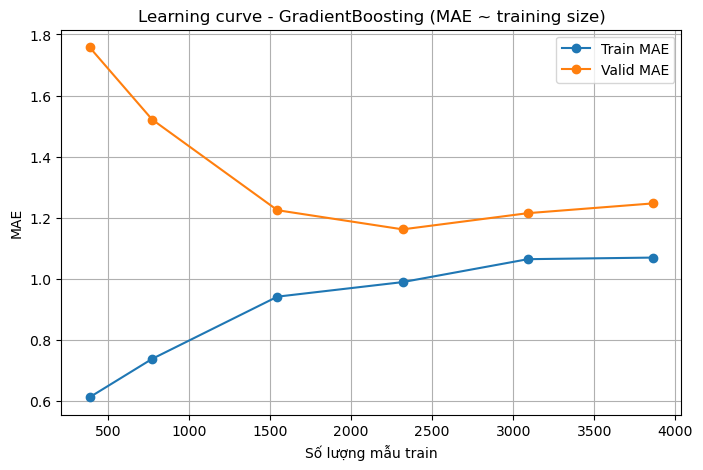

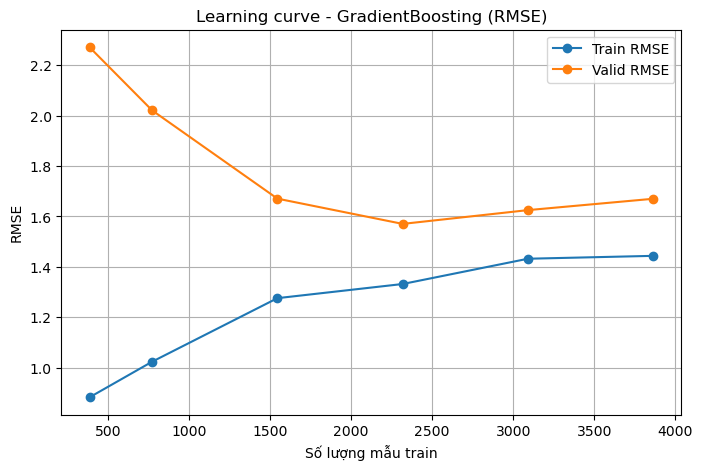

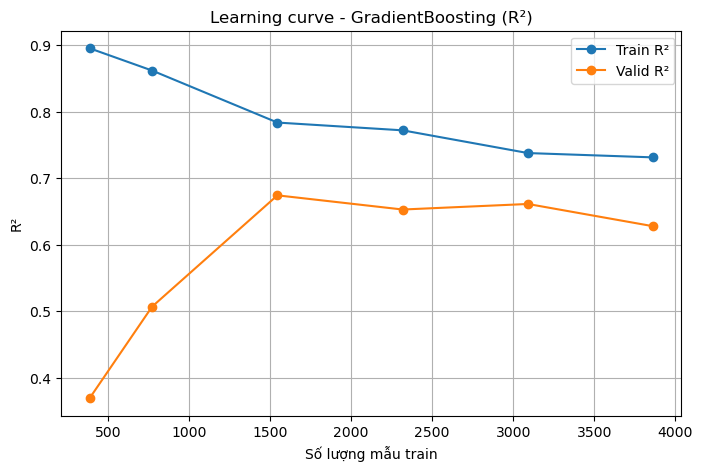

In [7]:
# MAE train & valid theo số lượng mẫu train
plt.figure(figsize=(8, 5))
plt.plot(lc_df["n_train"], lc_df["MAE_train"], marker="o", label="Train MAE")
plt.plot(lc_df["n_train"], lc_df["MAE_valid"], marker="o", label="Valid MAE")
plt.xlabel("Số lượng mẫu train")
plt.ylabel("MAE")
plt.title("Learning curve - GradientBoosting (MAE ~ training size)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Learning curve - GradientBoosting (MAE ~ training size).png"))
plt.show()

# (Optional) RMSE
plt.figure(figsize=(8, 5))
plt.plot(lc_df["n_train"], lc_df["RMSE_train"], marker="o", label="Train RMSE")
plt.plot(lc_df["n_train"], lc_df["RMSE_valid"], marker="o", label="Valid RMSE")
plt.xlabel("Số lượng mẫu train")
plt.ylabel("RMSE")
plt.title("Learning curve - GradientBoosting (RMSE)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Learning curve - GradientBoosting (RMSE).png"))
plt.show()

# (Optional) R²
plt.figure(figsize=(8, 5))
plt.plot(lc_df["n_train"], lc_df["R2_train"], marker="o", label="Train R²")
plt.plot(lc_df["n_train"], lc_df["R2_valid"], marker="o", label="Valid R²")
plt.xlabel("Số lượng mẫu train")
plt.ylabel("R²")
plt.title("Learning curve - GradientBoosting (R²)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Learning curve - GradientBoosting (R²).png"))
plt.show()


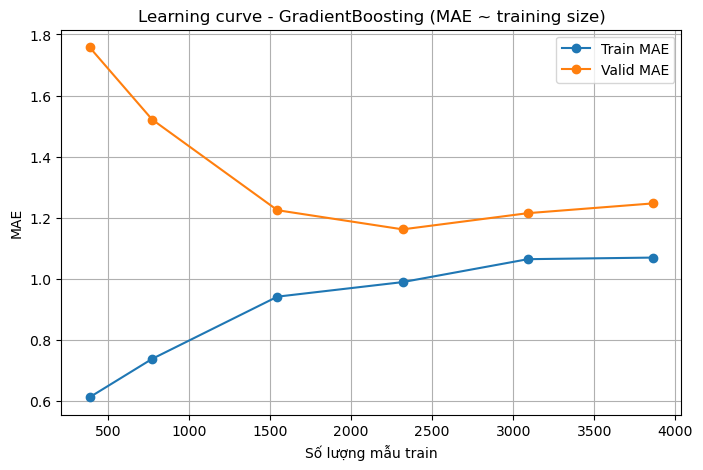

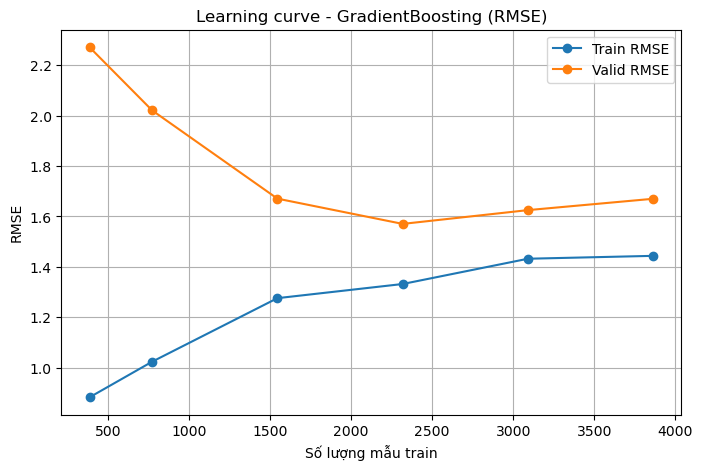

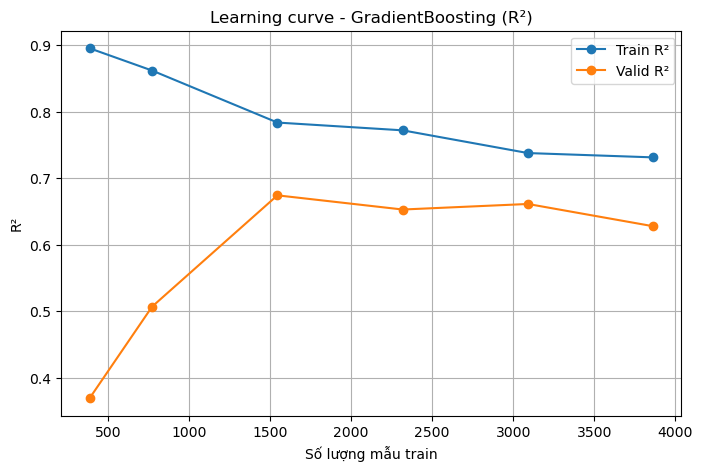

In [8]:
# MAE train & valid theo số lượng mẫu train
plt.figure(figsize=(8, 5))
plt.plot(lc_df["n_train"], lc_df["MAE_train"], marker="o", label="Train MAE")
plt.plot(lc_df["n_train"], lc_df["MAE_valid"], marker="o", label="Valid MAE")
plt.xlabel("Số lượng mẫu train")
plt.ylabel("MAE")
plt.title("Learning curve - GradientBoosting (MAE ~ training size)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Learning curve - GradientBoosting (MAE ~ training size).png"))
plt.show()

# (Optional) RMSE
plt.figure(figsize=(8, 5))
plt.plot(lc_df["n_train"], lc_df["RMSE_train"], marker="o", label="Train RMSE")
plt.plot(lc_df["n_train"], lc_df["RMSE_valid"], marker="o", label="Valid RMSE")
plt.xlabel("Số lượng mẫu train")
plt.ylabel("RMSE")
plt.title("Learning curve - GradientBoosting (RMSE)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Learning curve - GradientBoosting (RMSE).png"))
plt.show()

# (Optional) R²
plt.figure(figsize=(8, 5))
plt.plot(lc_df["n_train"], lc_df["R2_train"], marker="o", label="Train R²")
plt.plot(lc_df["n_train"], lc_df["R2_valid"], marker="o", label="Valid R²")
plt.xlabel("Số lượng mẫu train")
plt.ylabel("R²")
plt.title("Learning curve - GradientBoosting (R²)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "Learning curve - GradientBoosting (R²).png"))
plt.show()


In [9]:
# =======================================
# 8b. Inference với fallback dựa trên course_R2 (GradientBoosting)
# =======================================

# Map course_code -> R2 (GB) từ bảng metrics
course_r2_gb = df_course_gb.set_index("course_code")["R2"].to_dict()

# Đảm bảo baseline đã được fill trước đó
if "baseline_final_weighted" not in data.columns:
    data["baseline_final_weighted"] = np.nan

baseline_mean_all = data["baseline_final_weighted"].mean()
data["baseline_final_weighted"] = data["baseline_final_weighted"].fillna(baseline_mean_all)

# Gắn course_R2_gb vào từng dòng
data["course_R2_gb"] = data["course_code"].map(course_r2_gb)

# Ngưỡng fallback (bạn có thể chỉnh)
HIGH_R2 = 0.60   # tin model
MID_R2 = 0.30    # tin vừa vừa, dùng blend

# Mặc định: nếu không có R2 (course mới), xem như low-confidence
data["course_R2_gb"] = data["course_R2_gb"].fillna(-999)

# Khởi tạo cột final_pred & source & confidence
data["final_pred"] = np.nan
data["pred_source"] = "unknown"
data["confidence_level"] = "unknown"

# Các mask theo R2
mask_high = data["course_R2_gb"] >= HIGH_R2           # tin model
mask_mid  = (data["course_R2_gb"] >= MID_R2) & (data["course_R2_gb"] < HIGH_R2)
mask_low  = data["course_R2_gb"] < MID_R2             # fallback baseline / course mới

# HIGH: dùng thẳng pred_final_gb
data.loc[mask_high, "final_pred"] = data.loc[mask_high, "pred_final_gb"]
data.loc[mask_high, "pred_source"] = "gb_model"
data.loc[mask_high, "confidence_level"] = "high"

# MID: blend giữa model và baseline (70% model, 30% baseline)
alpha = 0.7
blend_mid = (
    alpha * data.loc[mask_mid, "pred_final_gb"] +
    (1 - alpha) * data.loc[mask_mid, "baseline_final_weighted"]
)
data.loc[mask_mid, "final_pred"] = blend_mid
data.loc[mask_mid, "pred_source"] = "gb_baseline_blend"
data.loc[mask_mid, "confidence_level"] = "medium"

# LOW: fallback hoàn toàn về baseline
data.loc[mask_low, "final_pred"] = data.loc[mask_low, "baseline_final_weighted"]
data.loc[mask_low, "pred_source"] = "baseline_only"
data.loc[mask_low, "confidence_level"] = "low"

# ✅ Tới đây, cột final_pred là prediction cuối cùng sau fallback
# Bạn có thể xem nhanh phân bố theo confidence_level:
print("\nSố lượng prediction theo confidence_level:")
print(data["confidence_level"].value_counts())

# Lưu file mới với final_pred
pred_csv_path_fallback = os.path.join(OUTPUT_DIR, "predictions_with_fallback_v2.csv")
data.to_csv(pred_csv_path_fallback, index=False, encoding="utf-8-sig")
print(f"Đã lưu dự đoán với fallback vào: {pred_csv_path_fallback}")



Số lượng prediction theo confidence_level:
confidence_level
low       1948
high      1722
medium    1160
Name: count, dtype: int64
Đã lưu dự đoán với fallback vào: ./output_final_v2\predictions_with_fallback_v2.csv


In [10]:
import joblib
import os

artifacts = {
    "gb_model": gb_model_es,
    "feature_cols": feature_cols,
    "mask_cols": mask_cols,
    "course_dummy_cols": list(course_dummies.columns),
    "baseline_fill_value": baseline_fill_value,
    "behavior_feature_cols": BEHAVIOR_FEATURE_BY_COURSE,
    "scaler_behavior": scaler_behavior,
}

ARTIFACTS_PATH = os.path.join(OUTPUT_DIR, "model_artifacts_gb_rf_add_feature.joblib")
joblib.dump(artifacts, ARTIFACTS_PATH)
print("Đã lưu artifacts vào:", ARTIFACTS_PATH)


Đã lưu artifacts vào: ./output_final_v2\model_artifacts_gb_rf_add_feature.joblib


In [11]:
model_path_pkl = os.path.join(OUTPUT_DIR, "model_artifacts_gb_rf_add_feature.pkl")
joblib.dump(artifacts, model_path_pkl)
print(f"Đã lưu model & artifacts (pkl) vào: {model_path_pkl}")


Đã lưu model & artifacts (pkl) vào: ./output_final_v2\model_artifacts_gb_rf_add_feature.pkl


In [12]:
def build_X_from_df_for_inference(
    df: pd.DataFrame,
    artifacts: dict,
    weights_by_course: Dict[str, Dict[str, float]],
    course_profile_scaled: pd.DataFrame
) -> (pd.DataFrame, pd.DataFrame):
    """
    Build X cho inference:
    - Tính baseline từ weights
    - Merge behavior feature theo course_code (đã scale)
    - Lấy đúng feature_cols + mask_cols + baseline
    - One-hot course_code
    """
    feature_cols = artifacts["feature_cols"]
    mask_cols = artifacts["mask_cols"]
    course_dummy_cols = artifacts["course_dummy_cols"]
    baseline_fill_value = artifacts.get("baseline_fill_value", 5.0)

    # 1) baseline từ weights
    df = add_baseline_from_weights(df, weights_by_course)

    if "baseline_final_weighted" not in df.columns:
        df["baseline_final_weighted"] = np.nan

    df["baseline_final_weighted"] = df["baseline_final_weighted"].fillna(baseline_fill_value)

    # 2) merge behavior feature (đã scale) theo course_code
    if course_profile_scaled is not None and not course_profile_scaled.empty:
        df = df.merge(course_profile_scaled, on="course_code", how="left")

    # 3) Numeric features
    X_num = df[feature_cols + mask_cols + ["baseline_final_weighted"]].copy()
    X_num = X_num.fillna(0.0)

    # 4) One-hot course_code
    course_dummies_new = pd.get_dummies(df["course_code"], prefix="course")

    for col in course_dummy_cols:
        if col not in course_dummies_new.columns:
            course_dummies_new[col] = 0
    course_dummies_new = course_dummies_new[course_dummy_cols]

    X_new = pd.concat([X_num, course_dummies_new], axis=1)

    return df, X_new


In [13]:
import joblib
import pandas as pd
import os

# 1. Load artifacts & weights
artifacts = joblib.load(os.path.join(OUTPUT_DIR, "model_artifacts_gb_rf_add_feature.joblib"))
weights_by_course_inf = load_weights(WEIGHTS_FILE)

# 1.1. Build course_profile_scaled để dùng cho inference
course_profile_scaled_inf = build_scaled_course_profile_for_inference(
    artifacts=artifacts,
    behavior_path=BEHAVIOR_FILE
)

# 2. Nhận file upload (ví dụ CMU-CS 462.csv)
uploaded_path = os.path.join(DATA_DIR, "CMU-CS 462.csv")  # thay bằng path thực tế

# 3. Chuẩn hóa file (dùng cùng hàm với training)
df_course = load_and_process_course_file(uploaded_path)

# 4. Build X_new (NHỚ truyền thêm course_profile_scaled_inf)
df_features, X_new = build_X_from_df_for_inference(
    df_course,
    artifacts=artifacts,
    weights_by_course=weights_by_course_inf,
    course_profile_scaled=course_profile_scaled_inf
)

# 5. Chọn model (GB làm model chính)
gb_model_loaded = artifacts["gb_model"]
pred_final = gb_model_loaded.predict(X_new)
pred_final = np.clip(pred_final, 0.0, 10.0)  # giống inference chính

df_features["pred_final_gb"] = pred_final

# 6. Lưu kết quả
output_pred_path = os.path.join(OUTPUT_DIR, "pred_for_uploaded_CMU_CS_462_fixed.csv")
df_features.to_csv(output_pred_path, index=False, encoding="utf-8-sig")
print("Đã lưu dự đoán:", output_pred_path)


Đã load weights cho 47 course.
Đã build course_profile từ behavior file.
Số course_code có profile: 56
Đang đọc file: output_final_fixed\CMU-CS 462.csv
Đã lưu dự đoán: ./output_final_v2\pred_for_uploaded_CMU_CS_462_fixed.csv
